# 04. Тематическое моделирование — BERTopic

Обучение BERTopic на мультиязычных эмбеддингах, визуализация тем и распределения документов, оценка когерентности.

In [1]:
from pathlib import Path
import sys
import ast
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import dendrogram, linkage

from gensim import corpora
from gensim.models import CoherenceModel
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

PROJECT_ROOT = Path(r"C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis")
if not PROJECT_ROOT.exists():
    PROJECT_ROOT = Path.cwd()

OUTPUT_DIR = PROJECT_ROOT / "outputs"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "figures"
SRC_DIR = PROJECT_ROOT / "src"

for p in (OUTPUT_DIR, MODELS_DIR, FIGURES_DIR):
    p.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(SRC_DIR))

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis


## 1. Загрузка предобработанных данных

In [2]:
df = pd.read_csv(OUTPUT_DIR / "clean_corpus.csv")
# В 01_data_preprocessing.ipynb токены сохранены как строка через пробел: "слово1 слово2 ..."
df["tokens"] = df["tokens"].apply(lambda x: x.split() if isinstance(x, str) else x)
df["text_for_bertopic"] = df["tokens"].apply(lambda x: " ".join(x) if isinstance(x, list) else "")

# Фильтрация пустых документов
df = df[df["text_for_bertopic"].str.len() > 0].reset_index(drop=True)

texts = df["tokens"].tolist()
docs  = df["text_for_bertopic"].tolist()

print(f"Документов для BERTopic: {len(df)}")

Документов для BERTopic: 6385


## 2. Настройка и обучение модели

In [3]:
# Русскоязычная/мультиязычная модель эмбеддингов
embedding_model = SentenceTransformer("intfloat/multilingual-e5-small")

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42,
)

hdbscan_model = HDBSCAN(
    min_cluster_size=10,
    metric="euclidean",
    cluster_selection_epsilon=0.1,
    prediction_data=True,
)

vectorizer_model = CountVectorizer(
    stop_words=[],        # Стоп-слова удалены на этапе предобработки
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.85,
    token_pattern=r"(?u)\b\w+\b",
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    top_n_words=15,
    verbose=True,
    calculate_probabilities=True,
)

print("Обучение BERTopic...")
topics, probabilities = topic_model.fit_transform(docs)

topic_model.save(str(MODELS_DIR / "bertopic_model"))
print("Модель сохранена:", MODELS_DIR / "bertopic_model")

2026-04-26 11:24:17,163 - BERTopic - Embedding - Transforming documents to embeddings.


Обучение BERTopic...


Batches: 100%|██████████| 200/200 [08:15<00:00,  2.48s/it]
2026-04-26 11:32:34,314 - BERTopic - Embedding - Completed ✓
2026-04-26 11:32:34,315 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-26 11:33:00,218 - BERTopic - Dimensionality - Completed ✓
2026-04-26 11:33:00,218 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-26 11:33:03,263 - BERTopic - Cluster - Completed ✓
2026-04-26 11:33:03,300 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-26 11:33:09,565 - BERTopic - Representation - Completed ✓
2026-04-26 11:33:13,122 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


Модель сохранена: C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\models\bertopic_model


## 3. Информация о темах

In [4]:
topic_info = topic_model.get_topic_info()
topic_info_valid = topic_info[topic_info["Topic"] != -1].copy()

n_topics   = len(topic_info_valid)
n_outliers = list(topics).count(-1)
n_assigned = len(topics) - n_outliers

print(f"Найдено тем: {n_topics}")
print(f"Документов в темах: {n_assigned}")
print(f"Документов-выбросов: {n_outliers} ({100*n_outliers/len(topics):.1f}%)")
print()
print("Топ-15 тем по размеру:")
print(topic_info_valid.head(15).to_string(index=False))

Найдено тем: 103
Документов в темах: 3632
Документов-выбросов: 2753 (43.1%)

Топ-15 тем по размеру:
 Topic  Count                                                  Name                                                                                                                                                                                                         Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [5]:
print("Примеры тем (первые 5):")
for topic_id in topic_info_valid["Topic"].values[:5]:
    words = topic_model.get_topic(topic_id)
    word_str = " + ".join(f"{w}({s:.3f})" for w, s in words[:10])
    count = topic_info_valid.loc[topic_info_valid["Topic"] == topic_id, "Count"].values[0]
    print(f"  Тема {topic_id} ({count} докум.): {word_str}")

Примеры тем (первые 5):
  Тема 0 (328 докум.): случайный(0.030) + распределение(0.026) + случайный величина(0.022) + величина(0.020) + вероятность(0.019) + статистика(0.012) + процесс(0.011) + оценка(0.010) + независимый(0.010) + гипотеза(0.008)
  Тема 1 (246 докум.): квантовый(0.035) + частица(0.029) + взаимодействие(0.018) + энергия(0.016) + состояние(0.016) + поле(0.015) + механика(0.013) + квантовый теория(0.013) + импульс(0.012) + гамильтониан(0.012)
  Тема 2 (191 докум.): язык(0.027) + автомат(0.019) + слово(0.014) + алгоритм(0.012) + рекурсивный(0.012) + конструктивный(0.011) + наз(0.011) + нек(0.010) + логика(0.010) + программа(0.010)
  Тема 3 (169 докум.): напряжение(0.031) + деформация(0.027) + материал(0.023) + ползучесть(0.019) + упругий(0.014) + пластина(0.013) + рис(0.013) + образец(0.013) + разрушение(0.012) + скорость(0.012)
  Тема 4 (106 докум.): матрица(0.046) + собственный(0.014) + периодический(0.009) + матричный(0.009) + устойчивость(0.008) + итерационный(0.008) + 

## 4. Визуализации

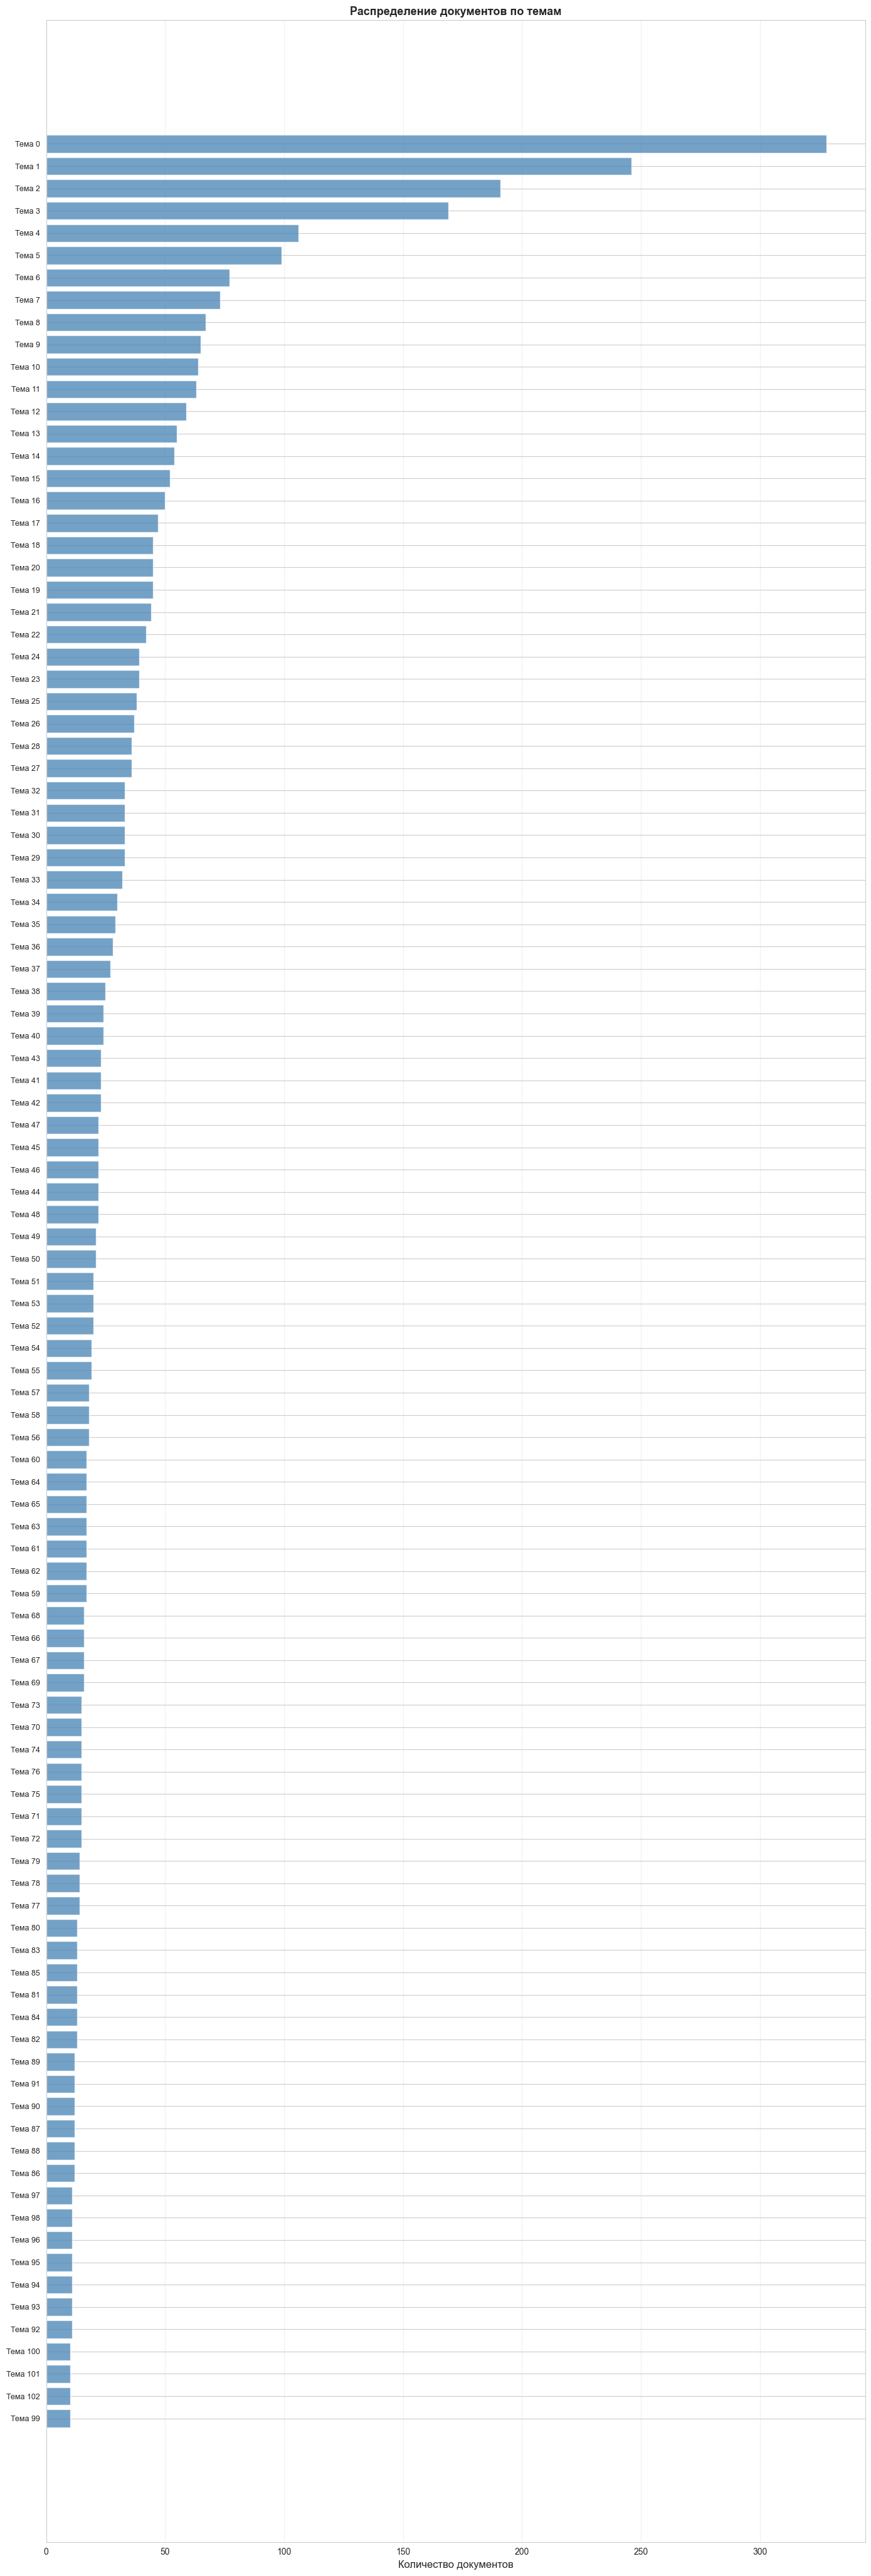

Сохранено: C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\figures\bertopic_topic_distribution.png


In [ ]:
# Распределение документов по темам
plot_df = topic_info_valid.sort_values("Count", ascending=True)

fig, ax = plt.subplots(figsize=(14, max(6, len(plot_df) * 0.4)))
ax.barh(range(len(plot_df)), plot_df["Count"].values, color="steelblue", alpha=0.75)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels([f"Тема {t}" for t in plot_df["Topic"].values], fontsize=9)
ax.set_xlabel("Количество документов", fontsize=12)
ax.set_title("Распределение документов по темам", fontsize=13, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "bertopic_topic_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
print("Сохранено:", FIGURES_DIR / "bertopic_topic_distribution.png")

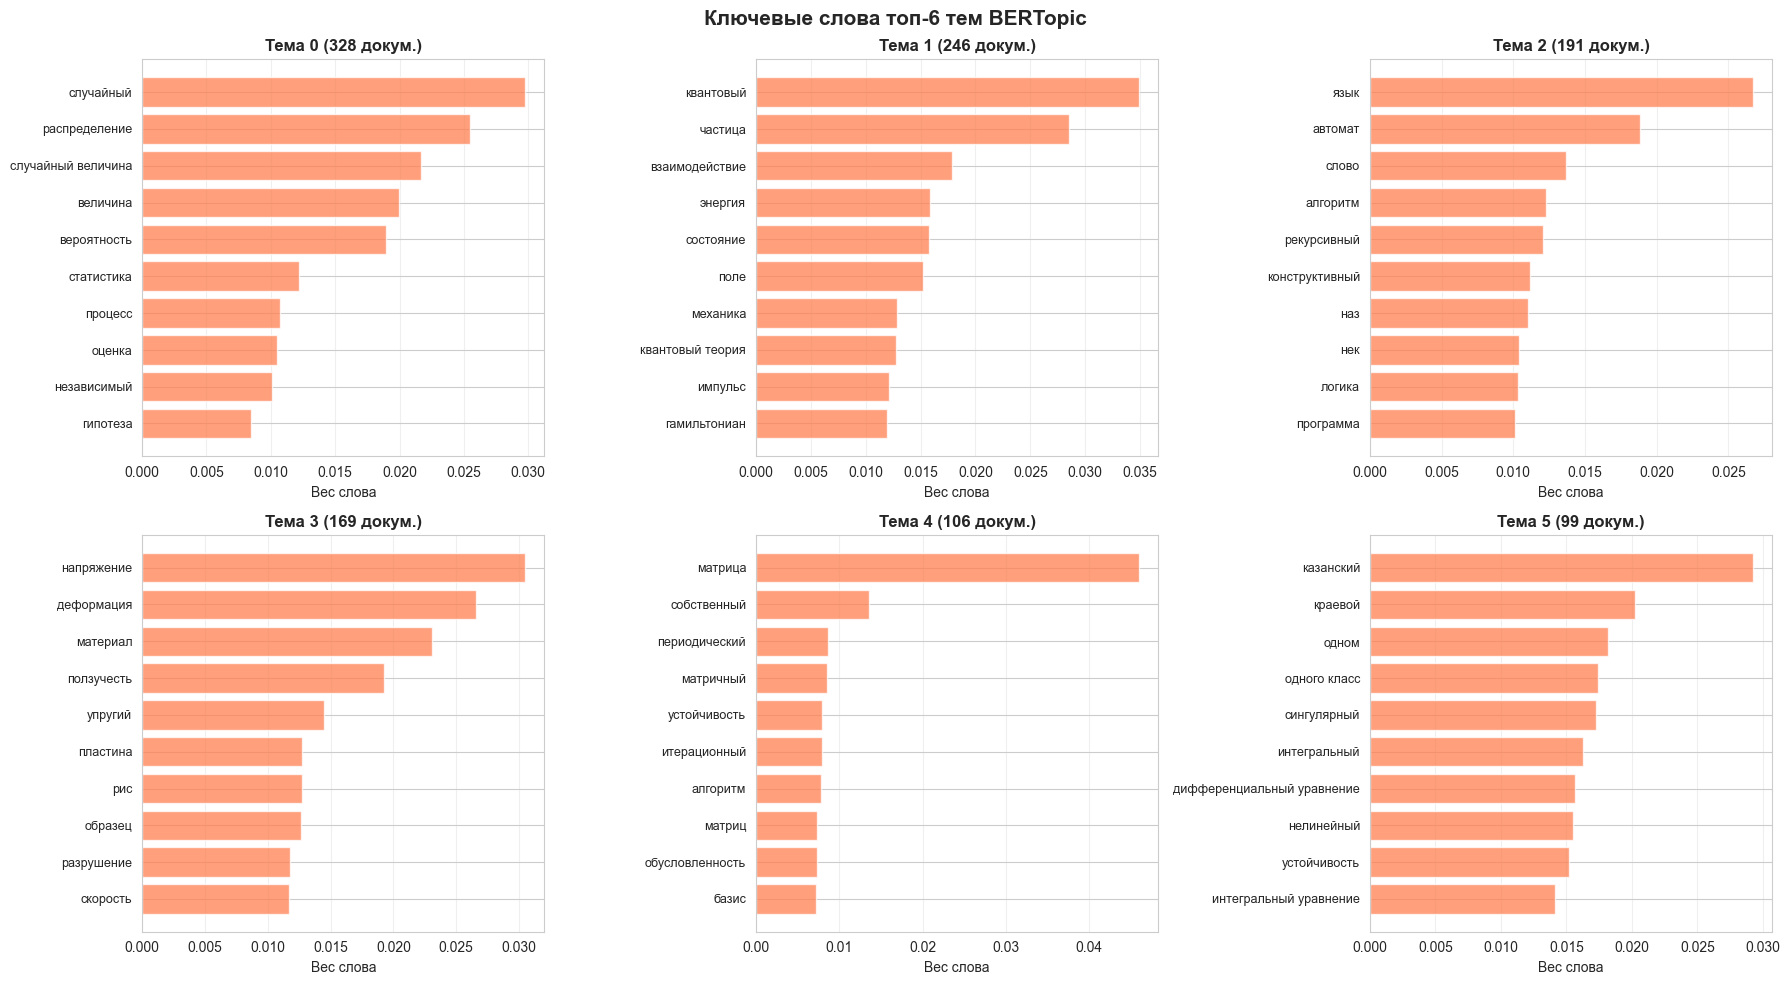

Сохранено: C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\figures\bertopic_top_topics_words.png


In [ ]:
# Ключевые слова топ-6 тем
top_topics = topic_info_valid.nlargest(6, "Count")["Topic"].values

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, topic_id in enumerate(top_topics):
    words  = topic_model.get_topic(topic_id)[:10]
    labels = [w for w, _ in words]
    scores = [s for _, s in words]
    count  = topic_info_valid.loc[topic_info_valid["Topic"] == topic_id, "Count"].values[0]
    ax = axes[i]
    ax.barh(range(len(labels)), scores, color="coral", alpha=0.75)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Вес слова")
    ax.set_title(f"Тема {topic_id} ({count} докум.)", fontweight="bold")
    ax.grid(axis="x", alpha=0.3)

for j in range(len(top_topics), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Ключевые слова топ-6 тем BERTopic", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "bertopic_top_topics_words.png", dpi=300, bbox_inches="tight")
plt.show()
print("Сохранено:", FIGURES_DIR / "bertopic_top_topics_words.png")

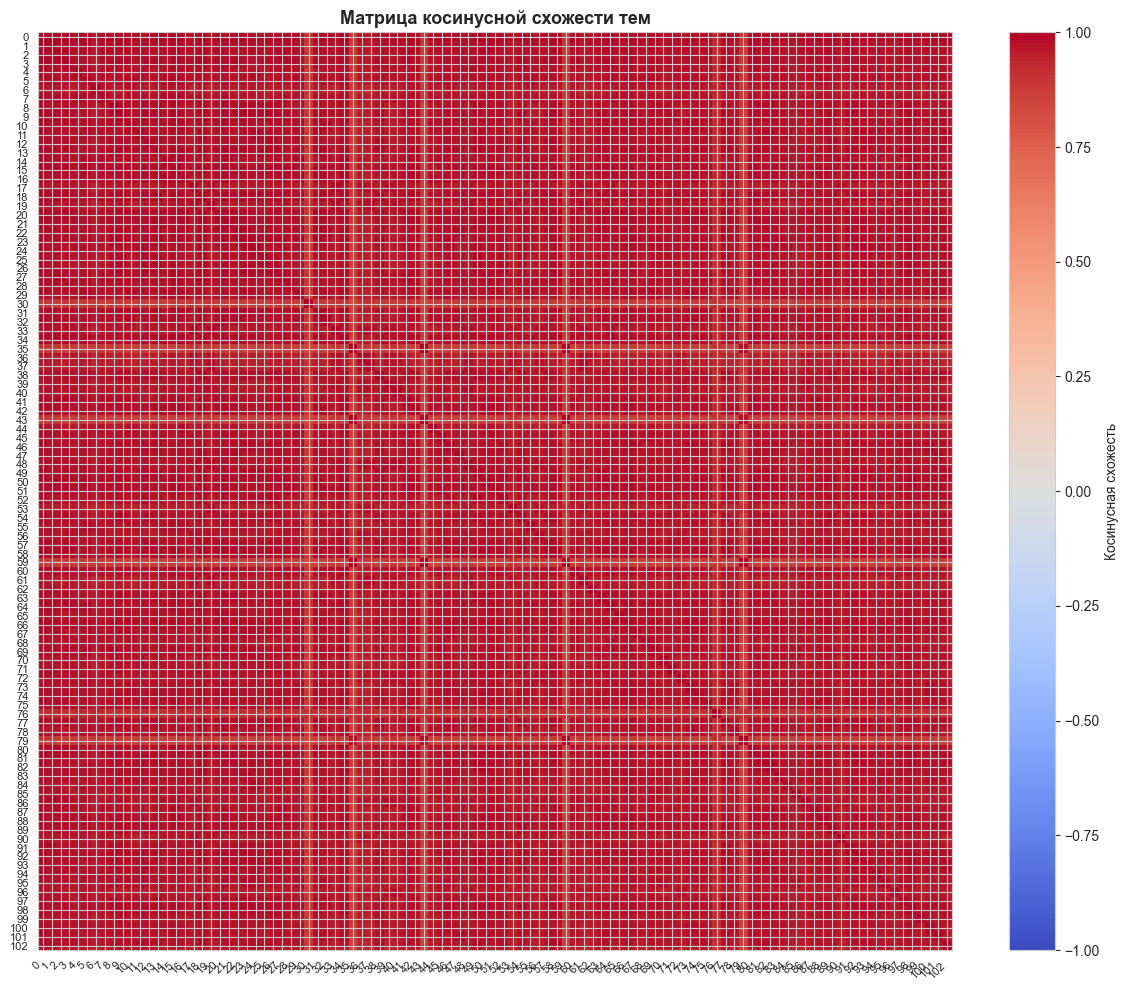

Сохранено: C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\figures\bertopic_similarity_matrix.png


In [ ]:
# Матрица косинусной схожести тем
topic_embeddings = topic_model.topic_embeddings_

if topic_embeddings is not None:
    topic_ids = sorted(topic_info_valid["Topic"].values)
    emb_subset = topic_embeddings[topic_ids]
    sim_matrix = cosine_similarity(emb_subset)

    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(sim_matrix, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(topic_ids)))
    ax.set_yticks(range(len(topic_ids)))
    ax.set_xticklabels([f"{t}" for t in topic_ids], rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels([f"{t}" for t in topic_ids], fontsize=8)
    ax.set_title("Матрица косинусной схожести тем", fontsize=13, fontweight="bold")
    plt.colorbar(im, ax=ax, label="Косинусная схожесть")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "bertopic_similarity_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Сохранено:", FIGURES_DIR / "bertopic_similarity_matrix.png")
else:
    print("topic_embeddings недоступны — пропускаем тепловую карту.")

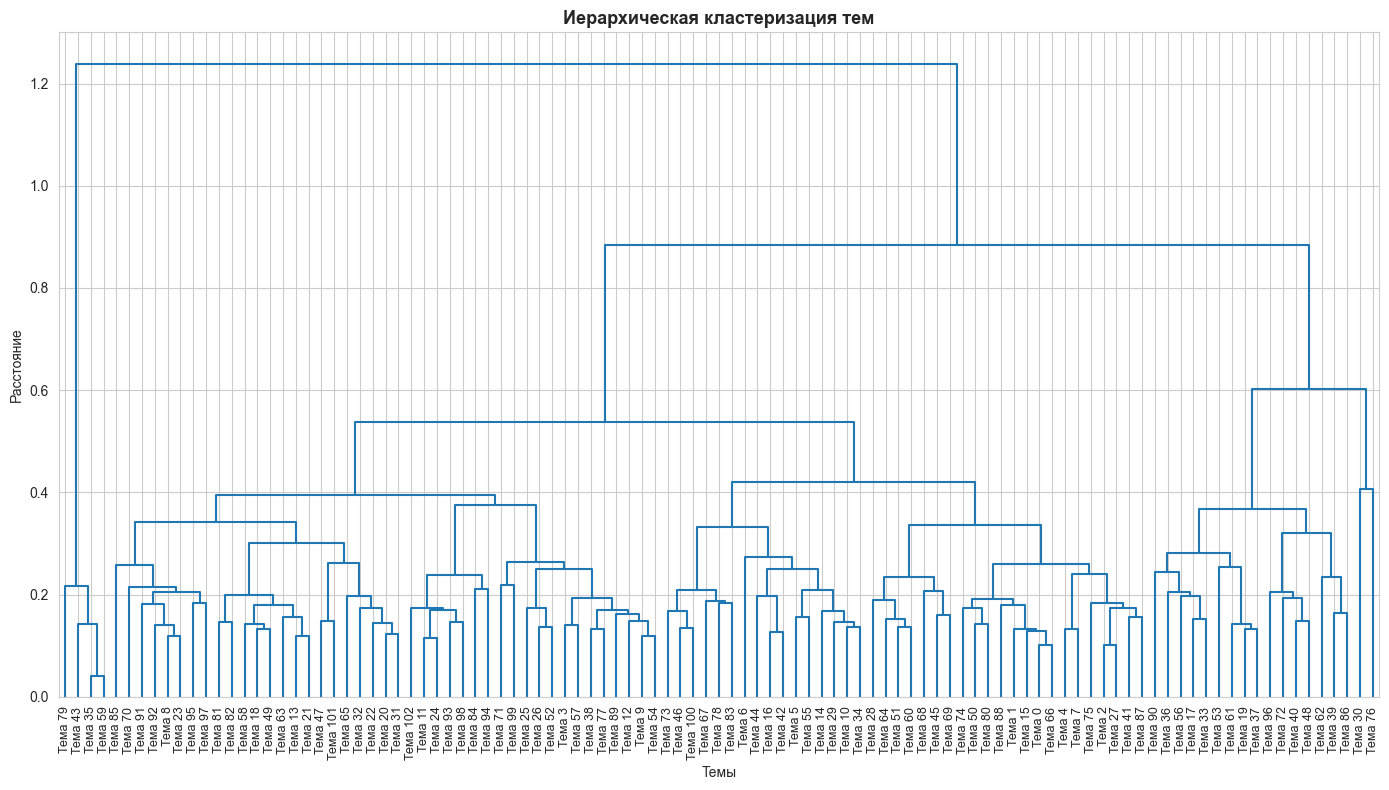

Сохранено: C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\figures\bertopic_dendrogram.png


In [ ]:
# Дендрограмма тем
if topic_embeddings is not None:
    linkage_matrix = linkage(emb_subset, method="ward", metric="euclidean")

    fig, ax = plt.subplots(figsize=(14, 8))
    dendrogram(
        linkage_matrix,
        labels=[f"Тема {t}" for t in topic_ids],
        ax=ax,
        leaf_rotation=90,
        leaf_font_size=9,
        color_threshold=0,
    )
    ax.set_title("Иерархическая кластеризация тем", fontsize=13, fontweight="bold")
    ax.set_xlabel("Темы")
    ax.set_ylabel("Расстояние")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "bertopic_dendrogram.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Сохранено:", FIGURES_DIR / "bertopic_dendrogram.png")

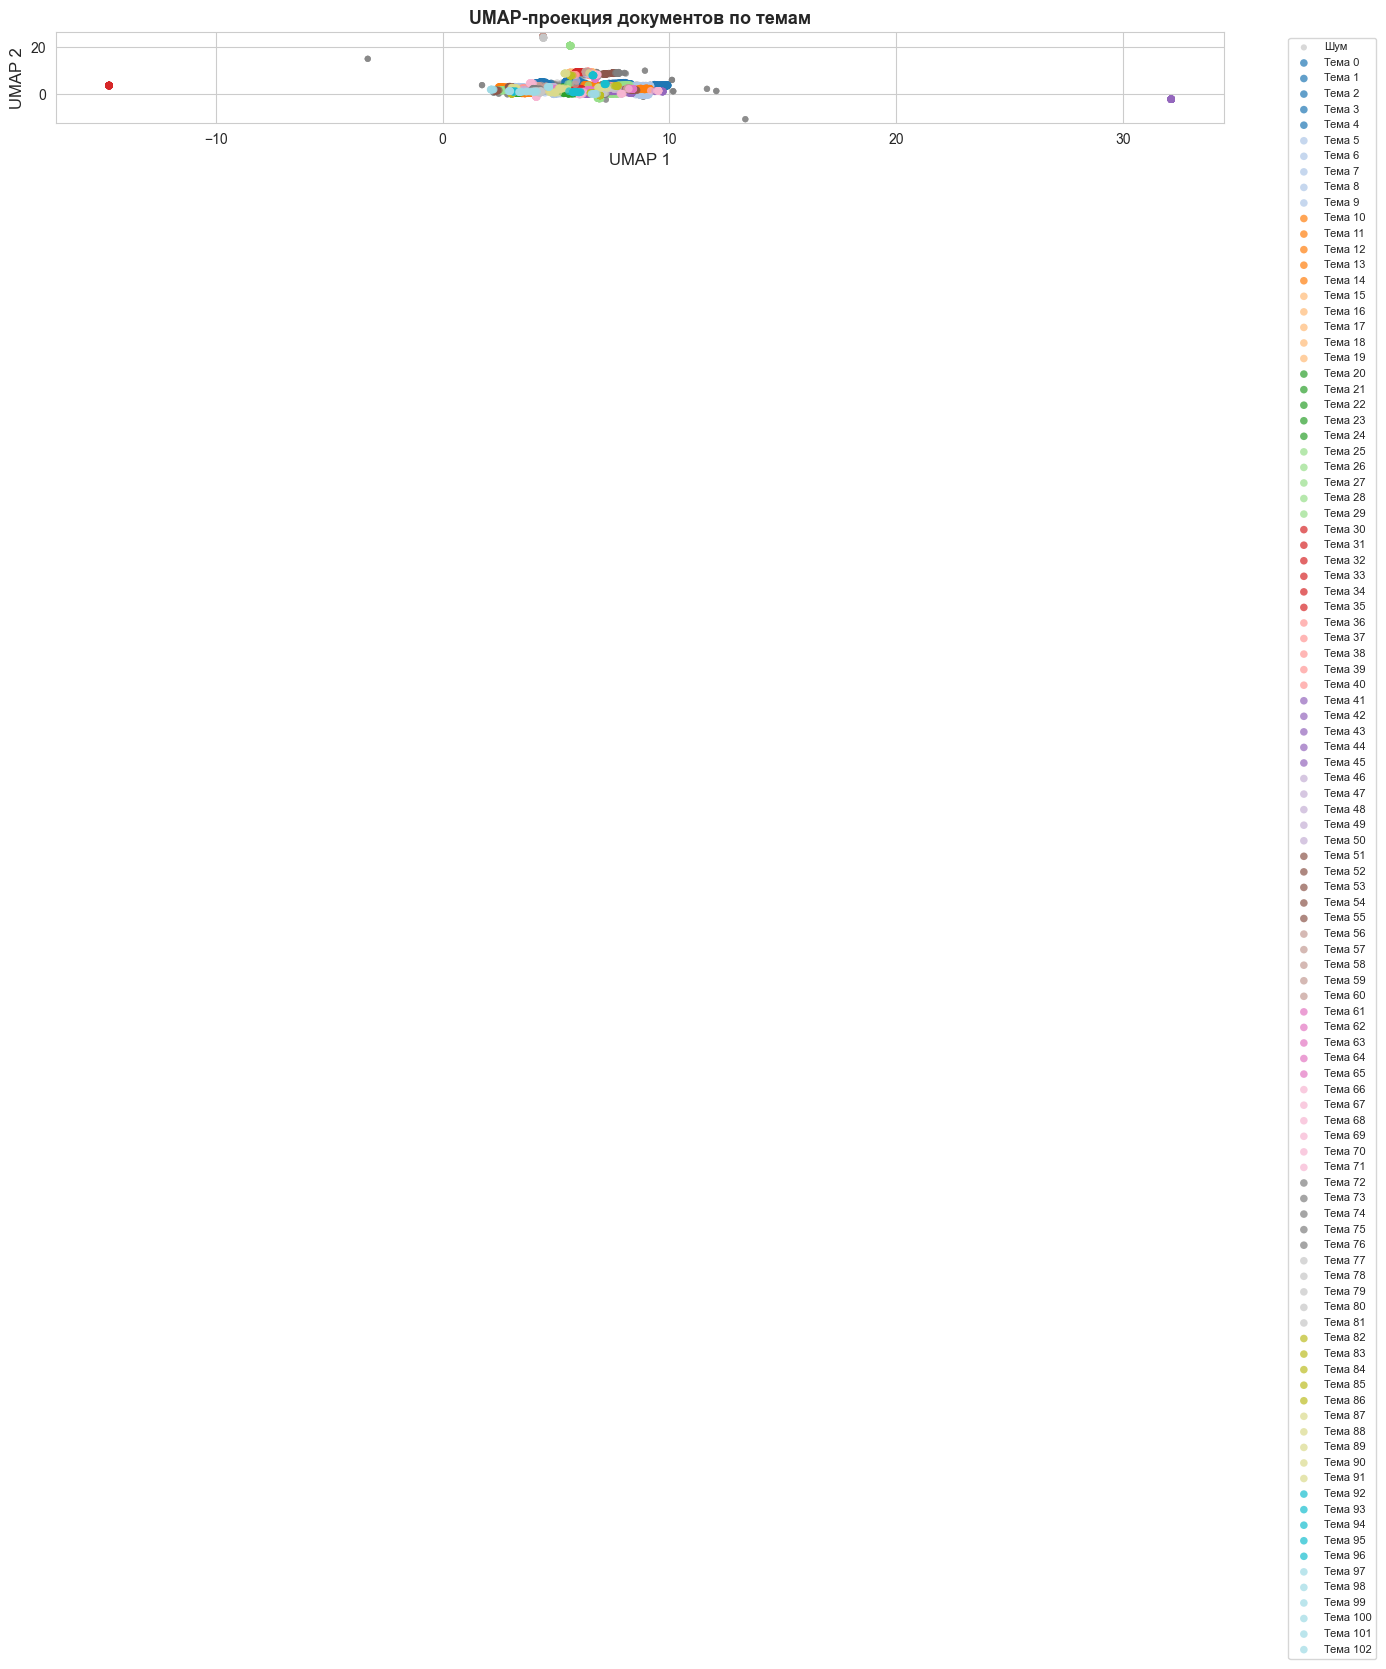

Сохранено: C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\figures\bertopic_umap_documents.png


In [10]:
# --- UMAP-проекция документов ---
embeddings = topic_model._extract_embeddings(docs)

umap_2d = UMAP(
    n_neighbors=15, n_components=2,
    min_dist=0.0, metric="cosine", random_state=42
)
reduced = umap_2d.fit_transform(embeddings)

unique_topics = sorted(set(topics))
color_map = plt.cm.tab20(np.linspace(0, 1, len(unique_topics)))

fig, ax = plt.subplots(figsize=(14, 10))
for i, tid in enumerate(unique_topics):
    mask = [t == tid for t in topics]
    if tid == -1:
        label, color, alpha, size = "Шум", "gray", 0.3, 20
    else:
        label, color, alpha, size = f"Тема {tid}", color_map[i], 0.7, 30
    ax.scatter(reduced[mask, 0], reduced[mask, 1],
               c=[color], label=label, alpha=alpha, s=size, edgecolors="none")

ax.set_xlabel("UMAP 1", fontsize=12)
ax.set_ylabel("UMAP 2", fontsize=12)
ax.set_title("UMAP-проекция документов по темам", fontsize=13, fontweight="bold")
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(),
          bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "bertopic_umap_documents.png", dpi=300, bbox_inches="tight")
plt.show()
print("Сохранено:", FIGURES_DIR / "bertopic_umap_documents.png")

## 5. Итоговые метрики качества

In [14]:
# Подготовка словаря для CoherenceModel
all_words = [w for doc in texts for w in doc]
coh_dictionary = corpora.Dictionary([all_words])

# Извлечение тем для оценки
topic_words_list = [
    [w for w, _ in topic_model.get_topic(tid)]
    for tid in topic_info_valid["Topic"].values
]

coherence_cv = CoherenceModel(
    topics=topic_words_list, texts=texts,
    dictionary=coh_dictionary, coherence="c_v"
).get_coherence()

coherence_umass = CoherenceModel(
    topics=topic_words_list, texts=texts,
    dictionary=coh_dictionary, coherence="u_mass"
).get_coherence()

print("Метрики финальной BERTopic модели")
print(f"  Когерентность c_v:    {coherence_cv:.4f}")
print(f"  Когерентность u_mass: {coherence_umass:.4f}")
print(f"  Число тем:            {n_topics}")
print(f"  Документов-выбросов:  {n_outliers} ({100*n_outliers/len(topics):.1f}%)")

pd.DataFrame([{
    "model": "BERTopic",
    "num_topics": n_topics,
    "coherence_cv": coherence_cv,
    "coherence_umass": coherence_umass,
    "perplexity": None,
}]).to_csv(OUTPUT_DIR / "bertopic_final_metrics.csv", index=False)
print("Метрики сохранены:", OUTPUT_DIR / "bertopic_final_metrics.csv")

Метрики финальной BERTopic модели
  Когерентность c_v:    0.6680
  Когерентность u_mass: -1.9205
  Число тем:            103
  Документов-выбросов:  2753 (43.1%)
Метрики сохранены: C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\outputs\bertopic_final_metrics.csv


## 6. Сводный отчёт

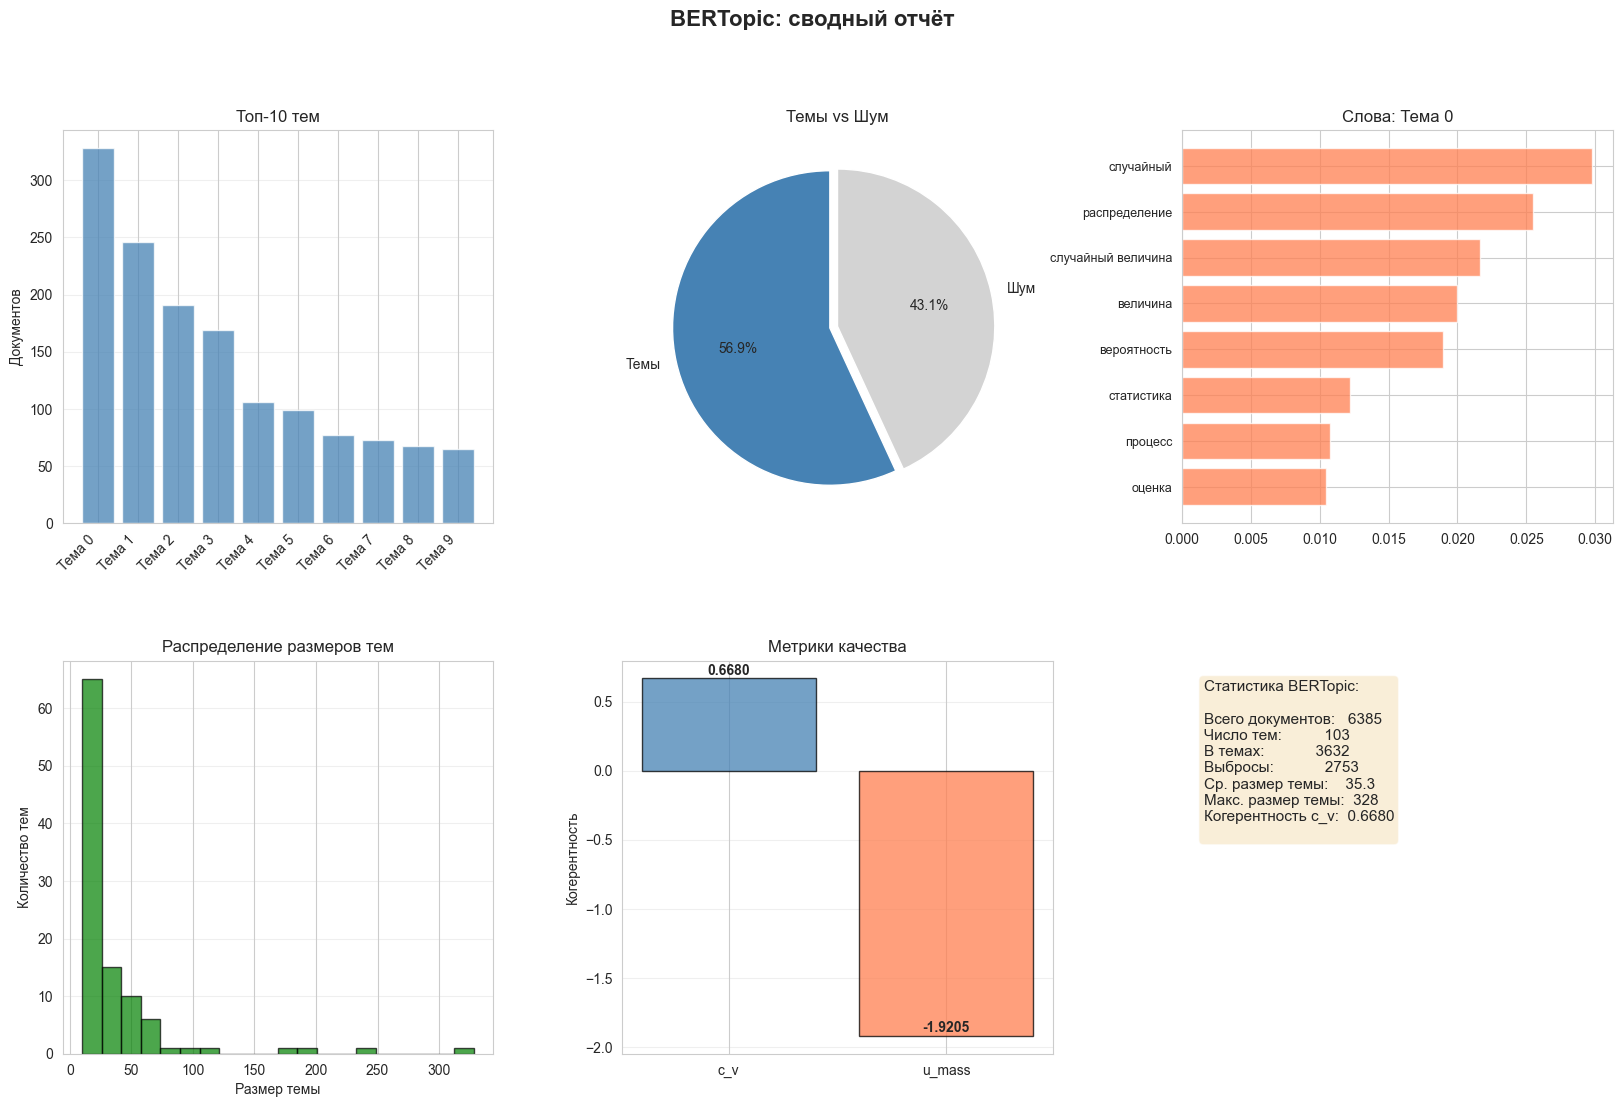

Сохранено: C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\figures\bertopic_summary_report.png


In [12]:
fig = plt.figure(figsize=(20, 12))
gs  = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3)

# Топ-10 тем по размеру
ax1 = fig.add_subplot(gs[0, 0])
top10 = topic_info_valid.nlargest(10, "Count")
ax1.bar(range(len(top10)), top10["Count"].values, color="steelblue", alpha=0.75)
ax1.set_xticks(range(len(top10)))
ax1.set_xticklabels([f"Тема {t}" for t in top10["Topic"].values],
                    rotation=45, ha="right")
ax1.set_ylabel("Документов")
ax1.set_title("Топ-10 тем")
ax1.grid(axis="y", alpha=0.3)

# Темы vs Шум
ax2 = fig.add_subplot(gs[0, 1])
ax2.pie([n_assigned, n_outliers], labels=["Темы", "Шум"],
        autopct="%1.1f%%", colors=["steelblue", "lightgray"],
        explode=(0.05, 0), startangle=90)
ax2.set_title("Темы vs Шум")

# Ключевые слова самой большой темы
ax3 = fig.add_subplot(gs[0, 2])
largest_tid = top10.iloc[0]["Topic"]
words  = topic_model.get_topic(largest_tid)[:8]
labels = [w for w, _ in words]
scores = [s for _, s in words]
ax3.barh(range(len(labels)), scores, color="coral", alpha=0.75)
ax3.set_yticks(range(len(labels)))
ax3.set_yticklabels(labels, fontsize=9)
ax3.invert_yaxis()
ax3.set_title(f"Слова: Тема {largest_tid}")

# Распределение размеров тем
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(topic_info_valid["Count"].values, bins=20,
         color="green", alpha=0.7, edgecolor="black")
ax4.set_xlabel("Размер темы")
ax4.set_ylabel("Количество тем")
ax4.set_title("Распределение размеров тем")
ax4.grid(axis="y", alpha=0.3)

# Когерентность
ax5 = fig.add_subplot(gs[1, 1])
metrics_names  = ["c_v", "u_mass"]
metrics_values = [coherence_cv, coherence_umass]
bars = ax5.bar(metrics_names, metrics_values,
               color=["steelblue", "coral"], alpha=0.75, edgecolor="black")
for bar, val in zip(bars, metrics_values):
    ax5.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.005, f"{val:.4f}",
             ha="center", va="bottom", fontweight="bold")
ax5.set_ylabel("Когерентность")
ax5.set_title("Метрики качества")
ax5.grid(axis="y", alpha=0.3)

# Текстовая статистика
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis("off")
stats_text = (
    f"Статистика BERTopic:\n\n"
    f"Всего документов:   {len(df)}\n"
    f"Число тем:          {n_topics}\n"
    f"В темах:            {n_assigned}\n"
    f"Выбросы:            {n_outliers}\n"
    f"Ср. размер темы:    {topic_info_valid['Count'].mean():.1f}\n"
    f"Макс. размер темы:  {topic_info_valid['Count'].max()}\n"
    f"Когерентность c_v:  {coherence_cv:.4f}\n"
)
ax6.text(0.05, 0.95, stats_text, transform=ax6.transAxes, fontsize=11,
         verticalalignment="top",
         bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.suptitle("BERTopic: сводный отчёт", fontsize=16, fontweight="bold")
plt.savefig(FIGURES_DIR / "bertopic_summary_report.png", dpi=300, bbox_inches="tight")
plt.show()
print("Сохранено:", FIGURES_DIR / "bertopic_summary_report.png")

## 7. Сохранение документов с метками тем

In [13]:
df["topic"] = topics
df.to_csv(OUTPUT_DIR / "documents_with_topics.csv", index=False, encoding="utf-8")
print("Сохранено:", OUTPUT_DIR / "documents_with_topics.csv")

Сохранено: C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\outputs\documents_with_topics.csv
